# Financial Transactions EDA

## Project Objective
The goal of this project is to clean and analyze a financial transaction dataset to extract meaningful business insights.
The dataset contains information about transactions such as product name, quantity, price, payment method and transaction status.

The main focus of this project is:
- Data cleaning
- Handling missing values
- Standardizing inconsistent data
- Calculating revenue
- Extracting business insights

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('data/dirty_financial_transactions.csv')

df.head(10)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed
5,T0006,2021-10-26,C4241,Smartphone,598.0,NaN,PayPal,Completed
6,NaN,2025-02-30,C1313,Laptop,10.0,NaN,credit card,Completed
7,T0008,2023-13-01,C4736,Headphones,669.0,-86.92126929493884,Cash,NaN
8,T0009,NaN,C3387,Tablet,10.0,461.70198437439694,PayPal,NaN
9,T0010,2025-02-30,C2846,Laptop,-1.0,404.8907066405689,creditcard,Pending


## Dataset Overview

Before starting the cleaning process, an initial exploration of the dataset was performed to understand its structure and data types.

The following checks were performed:

- `df.head()` to view the first few rows of the dataset
- `df.info()` to understand column data types and missing values
- `df.describe()` to view statistical summaries of numerical columns

This step helps identify potential data quality issues such as missing values, incorrect data types, and unusual distributions.

# Data Cleaning Process

In [10]:
df.describe()

,Quantity
count,94981.000000
mean,183.883914
std,299.292365
min,-10.000000
25%,-3.000000
50%,6.000000
75%,327.000000
max,1000.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      94982 non-null   object 
 1   Transaction_Date    95120 non-null   object 
 2   Customer_ID         95122 non-null   object 
 3   Product_Name        100000 non-null  object 
 4   Quantity            94981 non-null   float64
 5   Price               66503 non-null   object 
 6   Payment_Method      100000 non-null  object 
 7   Transaction_Status  83321 non-null   object 
dtypes: float64(1), object(7)
memory usage: 6.1+ MB


In [12]:
df.shape

(100000, 8)

In [13]:
df.isnull().sum()

Transaction_ID         5018
Transaction_Date       4880
Customer_ID            4878
Product_Name              0
Quantity               5019
Price                 33497
Payment_Method            0
Transaction_Status    16679
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      94982 non-null   object 
 1   Transaction_Date    95120 non-null   object 
 2   Customer_ID         95122 non-null   object 
 3   Product_Name        100000 non-null  object 
 4   Quantity            94981 non-null   float64
 5   Price               66503 non-null   object 
 6   Payment_Method      100000 non-null  object 
 7   Transaction_Status  83321 non-null   object 
dtypes: float64(1), object(7)
memory usage: 6.1+ MB


The Transaction_ID column is not clean. Some values are missing and a few IDs are not in sequence. Since transaction IDs should always be unique, using mode is not a good idea because it can create duplicate IDs. To avoid breaking uniqueness, a safer and more controlled approach is used to fix the sequence and clean the colum

In [15]:
# Remove extra spaces
df['Transaction_ID'] = df['Transaction_ID'].astype(str).str.strip()

# Extract numeric part from Transaction_ID
df['Transaction_ID'] = df['Transaction_ID'].str.extract(r'(\d+)')[0]

# Convert to numeric
df['Transaction_ID'] = pd.to_numeric(df['Transaction_ID'], errors='coerce')

# Fill missing sequence
df['Transaction_ID'] = range(1, len(df) + 1)

# Converting back
df['Transaction_ID'] = 'T' + df['Transaction_ID'].astype(str).str.zfill(4)
df.head(10)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed
5,T0006,2021-10-26,C4241,Smartphone,598.0,NaN,PayPal,Completed
6,T0007,2025-02-30,C1313,Laptop,10.0,NaN,credit card,Completed
7,T0008,2023-13-01,C4736,Headphones,669.0,-86.92126929493884,Cash,NaN
8,T0009,NaN,C3387,Tablet,10.0,461.70198437439694,PayPal,NaN
9,T0010,2025-02-30,C2846,Laptop,-1.0,404.8907066405689,creditcard,Pending


### Transaction ID Cleaning

During the data cleaning process it was observed that the `Transaction_ID` column contained inconsistent formatting such as extra spaces.

Since transaction IDs should uniquely identify each transaction, it is important that they remain clean and standardized.

Extra spaces were removed to ensure consistency and prevent incorrect grouping or duplication during analysis.

In [16]:
# Convert String into Datetime ,and invalid dates become Nan
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'],errors='coerce')
df.isnull().sum()

Transaction_ID            0
Transaction_Date      68261
Customer_ID            4878
Product_Name              0
Quantity               5019
Price                 33497
Payment_Method            0
Transaction_Status    16679
dtype: int64

### Transaction Date Cleaning

While inspecting the dataset, some invalid date values were found in the `Transaction_Date` column.

Examples of invalid dates include impossible calendar values such as incorrect months or days.

To handle these cases, the column was converted to datetime format using `errors='coerce'`, which automatically converts invalid values into `NaT` (missing datetime).

This ensures that date-based analysis can be performed reliably.

In [ ]:
# Fill missing Customer_ID with the most frequent value (mode)
df['Customer_ID'].fillna(df['Customer_ID'].mode()[0], inplace=True)

# Fill missing Transaction_Status with mode
df['Transaction_Status'].fillna(df['Transaction_Status'].mode()[0], inplace=True)

# First, mark negative Quantity as missing
df.loc[df['Quantity'] < 0, 'Quantity'] = None

# Fill missing Quantity with median (robust to outliers)
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)

# Fill missing Transaction_Date with median date
df['Transaction_Date'].fillna(df['Transaction_Date'].median(), inplace=True)

# Remove dollar sign
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)

# Convert Price to numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Replace negative prices with NaN
df.loc[df['Price'] < 0, 'Price'] = None

# Fill missing Price with median
df['Price'].fillna(df['Price'].median(), inplace=True)

# Convert to lowercase and remove extra spaces
df['Payment_Method'] = df['Payment_Method'].str.lower().str.strip()

# Remove spaces inside strings (like 'credit card' → 'creditcard')
df['Payment_Method'] = df['Payment_Method'].str.replace(' ', '')

# Replace with consistent naming
df['Payment_Method'] = df['Payment_Method'].replace({
    'creditcard': 'Credit Card',
    'paypal': 'PayPal',
    'cash': 'Cash'
})

# Convert to lowercase and strip spaces
df['Transaction_Status'] = df['Transaction_Status'].str.lower().str.strip()

# Remove spaces inside strings
df['Transaction_Status'] = df['Transaction_Status'].str.replace(' ', '')

# Replace with consistent naming
df['Transaction_Status'] = df['Transaction_Status'].replace({
    'failed': 'Failed',
    'pending': 'Pending',
    'completed': 'Completed',
    'complete': 'Completed'
})

In [18]:
df.head(5)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,106.0,420.210000,PayPal,Failed
1,T0002,2020-02-10,C3156,Coffee,469.0,523.881166,Credit Card,Pending
2,T0003,2022-07-26,C2919,Tablet,106.0,810.993012,Credit Card,Completed
3,T0004,2020-08-17,C3009,Tab,106.0,868.608341,PayPal,Pending
4,T0005,2022-07-26,C3488,Coffee Machine,106.0,523.881166,PayPal,Completed


In [19]:
df.isnull().sum()

Transaction_ID        0
Transaction_Date      0
Customer_ID           0
Product_Name          0
Quantity              0
Price                 0
Payment_Method        0
Transaction_Status    0
dtype: int64

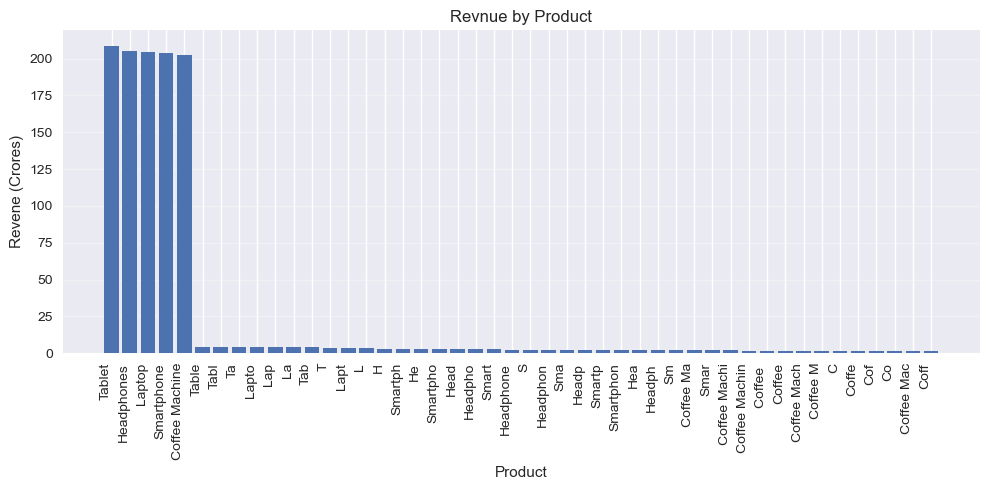

11280527698.621058


In [20]:
df['Revenue'] = df['Quantity'] * df['Price']
rev_prod = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False)
rev_prod = rev_prod / 1e7
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10,5))
plt.bar(rev_prod.index,rev_prod.values)
plt.xticks(rotation=90,ha='right')
plt.xlabel('Product')
plt.ylabel('Revene (Crores)')
plt.title('Revnue by Product')
plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()
print(df['Revenue'].sum())



### Insight Before Cleaning

While creating the revenue by product chart, the graph looked messy and unclear.

Many product names were showing in strange or incomplete forms like
"Tab", "Head", "Coff", etc. These are not real product names and
likely came from dirty or inconsistent data.

Because of this:
- Same products were getting split into multiple labels
- The chart looked crowded and confusing
- It was hard to identify the actual top-selling products

This indicated that the Product_Name column needed proper cleaning
before doing further analysis.

In [21]:
# Checking the Unique name
df['Product_Name'].unique()
# df['Product_Name'].value_counts()

array(['Headphones', 'Coffee ', 'Tablet', 'Tab', 'Coffee Machine',
       'Smartphone', 'Laptop', 'Coffee Ma', 'Cof', 'Smar', 'Coffee M',
       'T', 'Smartp', 'Headp', 'Smart', 'La', 'Lapt', 'Tabl', 'L', 'C',
       'Smartph', 'Hea', 'Head', 'Smartpho', 'Lapto', 'Headphon', 'Table',
       'Co', 'Headphone', 'Coffee Mac', 'Sm', 'Coffee', 'Headph', 'S',
       'Coffee Mach', 'Smartphon', 'Headpho', 'Coffee Machin', 'Coff',
       'Lap', 'H', 'He', 'Ta', 'Coffee Machi', 'Coffe', 'Sma'],
      dtype=object)

In [22]:
#Lowercase and strip the column temporarily
df['Product_Name_temp'] = df['Product_Name'].str.lower().str.strip()

# replacing the wrong product name with original
replace_name = {
    'tab' : 'Tablet',
    'coffee ma' : 'Coffee Machine',
    'coffee' : 'Coffee Machine',
    'cof' : 'Coffee Machine',
    'smar' : 'Smartphone',
    'coffee m' : 'Coffee Machine',
    't' : 'Tablet',
    'smartpho' : 'Smartphone',
    'headp' : 'Headphones',
    'smart' : 'Smartphone',
    'smartph':'Smartphone',
    'la' : 'Laptop',
    'lapt' : 'Laptop',
    'tabl' : 'Tablet',
    'l' : 'Laptop',
    'c' : 'Coffee Machine',
    'co' : 'Coffee Machine',
    'headphone': 'Headphones',
    'coffee mac' : 'Coffee Machine',
    'sm' : 'Smartphone',
    'headph' : 'Headphones',
    's' : 'Smartphone',
    'coffee mach' : 'Coffee Machine',
    'smartphon' : 'Smartphone',
    'headpho' : 'Headphones',
    'coffee machin' : 'Coffee Machine',
    'coff' : 'Coffee Machine',
    'lap' : 'Laptop',
    'h' : 'Headphones',
    'he' : 'Headphones',
    'ta': 'Tablet',
    'coffee machi' : 'Coffee Machine',
    'coffe' : 'Coffee Machine',
    'sma' : 'Smartphone',
    'smartp' : 'Smartphone',
    'hea' : 'Headphones',
    'headphon': 'Headphones',
    'head' : 'Headphones',
    'lapto' :  'Laptop',
    'table' : 'Tablet'
}

# replacing using lowercase column
df['Product_Name_temp'] = df['Product_Name_temp'].replace(replace_name)

# Converting back to capital latter
df['Product_Name'] = df['Product_Name_temp'].str.title()

#Drop temporary column
df.drop(columns=['Product_Name_temp'], inplace=True)

df['Product_Name'].value_counts()

Product_Name
Tablet            20151
Smartphone        20067
Laptop            19980
Headphones        19934
Coffee Machine    19868
Name: count, dtype: int64

### Product Name Cleaning

After detecting inconsistencies in product names, the `Product_Name` column was cleaned and standardized.

The cleaning process involved:

- Converting product names to lowercase and removing extra spaces
- Mapping incomplete or incorrect names (such as "cof", "smar", "lap", etc.) to their correct product names using a replacement dictionary
- Converting the cleaned names back to title case for better readability

This process ensured that all variations of the same product were grouped under a single correct category.

After cleaning, the product distribution became clearer and the revenue analysis by product became more reliable.

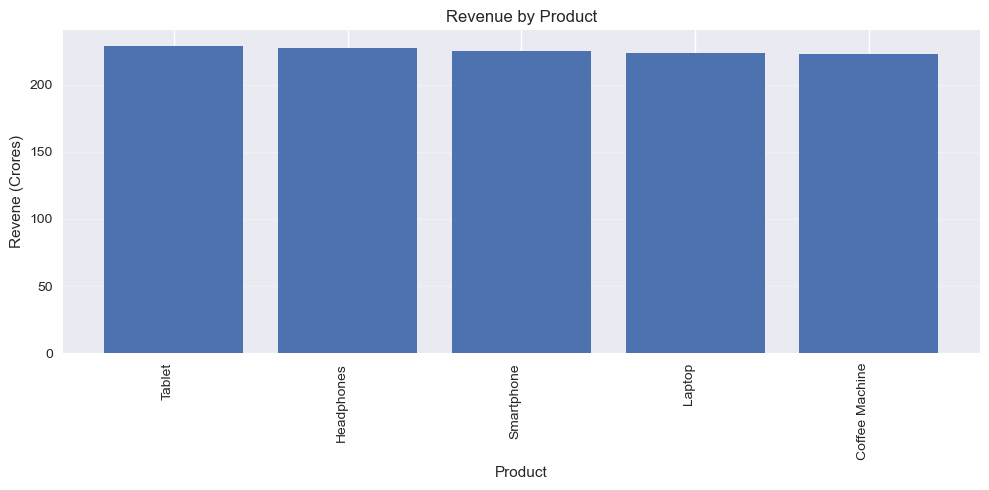

11280527698.621058


In [ ]:
# Calculate revenue for each transaction
# Revenue = Quantity * Price
df['Revenue'] = df['Quantity'] * df['Price']

# Sum revenue per product and sort in descending order
# This helps identify top-revenue products
rev_prod = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False)

# Convert revenue to Crores (1 Crore = 10 million) for easier readability on chart
rev_prod = rev_prod / 1e7

# Set plot style using seaborn for better aesthetics
plt.style.use('seaborn-v0_8')

# Create the bar chart for product-wise revenue
plt.figure(figsize=(10,5))
plt.bar(rev_prod.index, rev_prod.values)

# Rotate x-axis labels to avoid overlap and improve readability
plt.xticks(rotation=90, ha='right')

# Label x-axis and y-axis
plt.xlabel('Product')
plt.ylabel('Revenue (Crores)')

# Add chart title
plt.title('Revenue by Product')

# Add horizontal grid lines for better visualization of values
plt.grid(axis='y', alpha=0.3)

# Adjust layout so labels and chart elements do not overlap
plt.tight_layout()
plt.show()

# Print total revenue from all transactions for reference
print("Total Revenue:", df['Revenue'].sum())

### Revenue Feature Creation

To analyze the financial value of each transaction, a new column called **Revenue** was created.

Revenue represents the total value generated from a transaction and was calculated using the formula:

Revenue = Quantity × Price

This feature allows us to perform further analysis such as revenue by product, payment method, and transaction status.

Creating this column helps measure the actual business performance and identify the most valuable products and transactions.

In [ ]:
# Filter only completed transactions
df_completed_transaction = df[df['Transaction_Status'] == 'Completed']

# Calculate revenue for each transaction: Quantity * Price
df_completed_transaction['Revenue'] = df_completed_transaction['Quantity'] * df_completed_transaction['Price']

# Sum all revenue from completed transactions
total_completed_revenue = df_completed_transaction['Revenue'].sum()
print("Total Revenue from Completed Transactions:", total_completed_revenue)

5597784238.14128


### Actual Revenue Analysis

Checking revenue on raw data is risky because it includes money from transactions that were **Failed or Pending**, meaning the payment never actually reached the business.

To get a more accurate picture of financial performance, the dataset was filtered to include only transactions with the status **Completed**.

This allows us to analyze the **actual cash flow** and identify which products truly generate revenue for the business.

In [25]:
print(df['Transaction_Status'].value_counts())

Transaction_Status
Completed    49931
Failed       33474
Pending      16595
Name: count, dtype: int64


Top Product:  Tablet


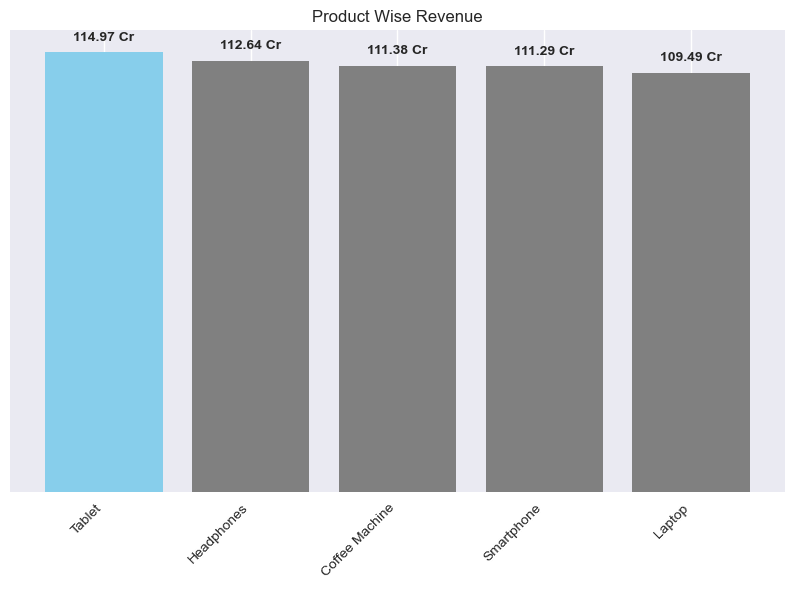

In [ ]:
# Revenue = Quantity * Price
df_completed_transaction['Revenue'] = df_completed_transaction['Quantity'] * df_completed_transaction['Price']

# Sum revenue by each product
rev_prod = df_completed_transaction.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False)

# Identify the top-selling product
top_selling_product = rev_prod.idxmax()
print('Top Product:', top_selling_product)

# Set colors: highlight top-selling product in skyblue, others in grey
colors = []
for c in rev_prod.index:
    if c == top_selling_product:
        colors.append('skyblue')
    else:
        colors.append('grey')

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.bar(rev_prod.index, rev_prod.values, color=colors)

# Add revenue labels on top of bars in Crores
for i, val in enumerate(rev_prod.values):
    plt.text(i, val + (rev_prod.max() * 0.02), f'{val/1e7:.2f} Cr',
             ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_visible(False)
plt.title("Product-wise Revenue from Completed Transactions")
plt.show()

### Revenue Contribution by Product (Completed Transactions)

After filtering only completed transactions, the revenue distribution across products became clearer.

From the analysis, the top revenue-generating products are:

- **Tablet** generates the highest revenue at approximately **114.97 Cr**
- **Headphones** follow closely with around **112.64 Cr**
- **Coffee Machine** contributes about **111.38 Cr**
- **Smartphone** generates roughly **111.29 Cr**
- **Laptop** contributes around **109.49 Cr**

Overall, the revenue across products appears relatively balanced, with tablets slightly leading the sales.

This indicates that demand for all major product categories is fairly strong, and no single product overwhelmingly dominates the revenue stream.

#Real Revenue After Removing Failed Transactions
While working on the revenue analysis, I noticed that failed and pending transactions were also getting counted, which can create confusion. Since only successful transactions should be considered as revenue, I removed the failed ones and recalculated the values. The updated result gives a more accurate picture of the actual earnings

In [ ]:
# Count how many transactions are in each status
df['Transaction_Status'].value_counts()

# Sum of revenue grouped by transaction status
df.groupby('Transaction_Status')['Revenue'].sum().sort_values(ascending=False)

# Total revenue from all transactions
total_revenue = df['Revenue'].sum()

# Revenue from Completed transactions
completed_revenue = df.loc[df['Transaction_Status'] == 'Completed', 'Revenue'].sum()

# Revenue from Pending transactions
pending_revenue = df.loc[df['Transaction_Status'] == 'Pending', 'Revenue'].sum()

# Revenue from Failed transactions
failed_revenue = df.loc[df['Transaction_Status'] == 'Failed', 'Revenue'].sum()


print('Total Revenue:', total_revenue)
print('Completed Revenue:', completed_revenue)
print('Pending Revenue:', pending_revenue)
print('Failed Revenue:', failed_revenue)

total_revenue 11280527698.621058
Completed: 5597784238.14128
Pending: 1871426077.1352298
Failed: 3811317383.344547


### Revenue Distribution by Transaction Status

To better understand the overall financial flow, revenue was analyzed based on the **transaction status**.

The results show:

- **Total Revenue:** ~11.28 Billion
- **Completed Transactions:** ~5.59 Billion
- **Pending Transactions:** ~1.87 Billion
- **Failed Transactions:** ~3.81 Billion

This analysis highlights that a significant portion of potential revenue is currently tied up in **pending or failed transactions**.

Only the **completed transactions represent actual realized revenue**, while pending and failed transactions indicate potential operational or payment processing issues that may require further investigation.

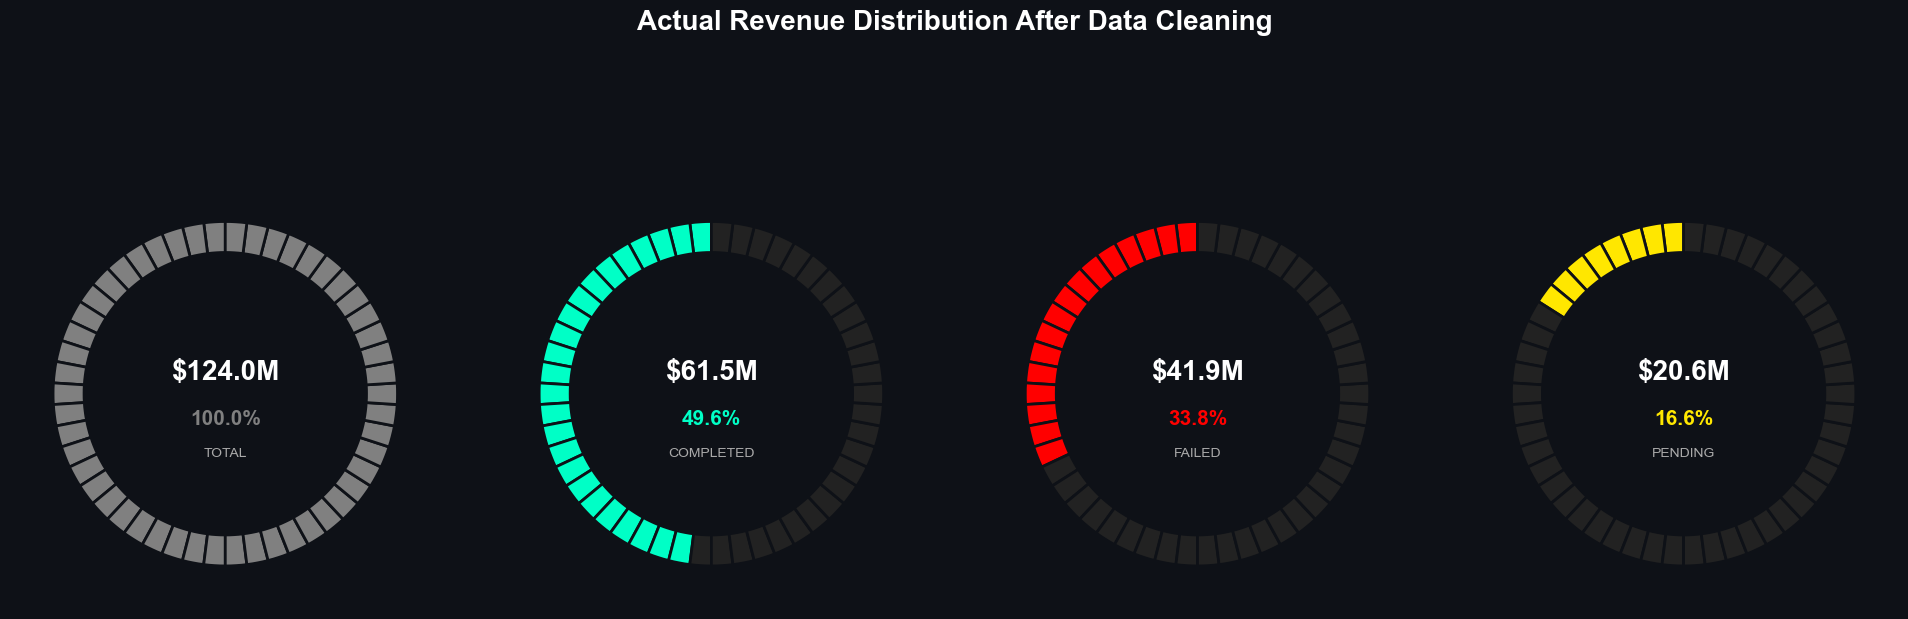

In [ ]:
# This is our revenue data for different transaction statuses
# Each entry has a label, amount in INR, and a color for the chart
data = [
    {'label': 'Total','amount_inr': 11280527698.621056,'color':'grey'},
    {'label': 'Completed','amount_inr':5597784238.14128,'color': '#00FFC6'},
    {'label': 'Failed','amount_inr': 3811317383.3445473,'color':'red'},
    {'label': 'Pending','amount_inr':1871426077.1352298,'color': '#FFE700'}
]

# Total revenue and USD conversion rate
total_revenue_inr = 11280527698.621056
usd_rate = 91

# Create 4 subplots for each category
fig, axes = plt.subplots(1, 4, figsize=(20, 8))
fig.patch.set_facecolor('#0E1117')  # dark background for a cool dashboard look

# Function to draw a ring chart for a single category
def dashboard(ax, amount_inr, color, label, total_inr):
    # Calculate the percentage of total revenue
    pct = (amount_inr / total_inr) * 100

    total_segment = 50  # total segments in the ring
    completed_segment = int((pct / 100) * total_segment)
    size = [1] * total_segment  # dummy sizes for the pie chart

    # Decide ring colors
    if label.lower() == 'total':
        ring_color = [color] * total_segment
        pct = 100.0  # total is always 100%
    else:
        ring_color = [color] * completed_segment + ['#222222'] * (total_segment - completed_segment)

    # Draw the pie/ring chart
    ax.pie(size,
           colors=ring_color,
           startangle=90,
           wedgeprops={'width': 0.18, 'edgecolor':'#0E1117', 'linewidth':2})

    # Convert INR to USD
    amount_usd = amount_inr / usd_rate

    # Format large numbers for readability (M for million, B for billion)
    if amount_usd >= 1_000_000_000:
        display_text = f'${amount_usd / 1_000_000_000:.2f}B'
    else:
        display_text = f'${amount_usd / 1_000_000:.1f}M'

    # Show USD amount in the center
    ax.text(0, 0.12, display_text, ha='center', va='center',
            fontsize=20, color='white', fontweight='bold')

    # Show percentage just below the center
    ax.text(0, -0.15, f'{pct:.1f}%', ha='center', va='center',
            fontsize=15, color=color, fontweight='bold')

    # Show the label at the bottom
    ax.text(0, -0.35, label.upper(), ha='center', va='center',
            fontsize=10, color='#aaaaaa')

    ax.set_aspect('equal')  # make sure the chart is perfectly circular

# Loop through each data category and plot the ring chart
for i, item in enumerate(data):
    dashboard(axes[i], item['amount_inr'], item['color'], item['label'], total_revenue_inr)

# Total revenue in USD for reference
total_usd = total_revenue_inr / usd_rate
plt.tight_layout(pad=4.0)
plt.suptitle("Actual Revenue Distribution After Data Cleaning",
             color="white", fontsize=20, fontweight="bold")
plt.show()

### Revenue Distribution by Transaction Status

To understand how revenue flows through different transaction outcomes, a donut dashboard visualization was created.

The chart shows that the **total revenue in the dataset is approximately $124.0M (100%)**.


**Completed Transactions**

Completed transactions generate around **$61.5M**, which accounts for **49.6% of the total revenue**.  
This represents the **actual revenue successfully received by the business**.


**Failed Transactions**

Failed transactions contribute approximately **$41.9M**, making up **33.8% of the total revenue**.  
This indicates that a significant portion of potential revenue was **lost due to unsuccessful transactions**.


**Pending Transactions**

Pending transactions account for about **$20.6M**, which is **16.6% of the total revenue**.  
These transactions are still **in progress and have not yet been finalized**.


Overall, the visualization highlights a noticeable gap between **potential revenue and realized revenue**, suggesting that improving transaction success rates could significantly increase the company's actual earnings.

In [29]:
df.head(10)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Revenue
0,T0001,2024-08-02,C2205,Headphones,106.0,420.210000,PayPal,Failed,44542.260000
1,T0002,2020-02-10,C3156,Coffee Machine,469.0,523.881166,Credit Card,Pending,245700.266954
2,T0003,2022-07-26,C2919,Tablet,106.0,810.993012,Credit Card,Completed,85965.259314
3,T0004,2020-08-17,C3009,Tablet,106.0,868.608341,PayPal,Pending,92072.484180
4,T0005,2022-07-26,C3488,Coffee Machine,106.0,523.881166,PayPal,Completed,55531.403619
5,T0006,2021-10-26,C4241,Smartphone,598.0,523.881166,PayPal,Completed,313280.937395
6,T0007,2022-07-26,C1313,Laptop,10.0,523.881166,Credit Card,Completed,5238.811662
7,T0008,2022-07-26,C4736,Headphones,669.0,523.881166,Cash,Failed,350476.500196
8,T0009,2022-07-26,C3387,Tablet,10.0,461.701984,PayPal,Failed,4617.019844
9,T0010,2022-07-26,C2846,Laptop,106.0,404.890707,Credit Card,Pending,42918.414904


Failed Payment:  Payment_Method
Cash            4741
Credit Card    14494
PayPal         14239
dtype: int64


<Figure size 1000x600 with 0 Axes>

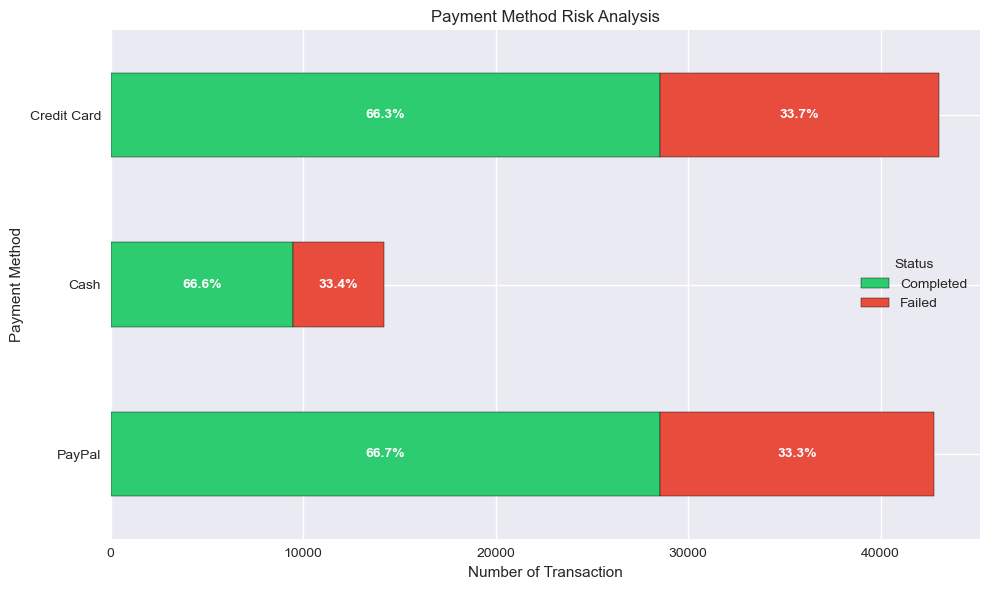

In [ ]:
# Count total transactions per payment method
total_pay_method = df.groupby('Payment_Method').size()

# Count failed transactions per payment method
failed_pay_method = df[df['Transaction_Status'] == 'Failed'].groupby('Payment_Method').size()
print('Failed Payment: ', failed_pay_method)

# Calculate successful transactions by subtracting failed from total
success_pay_method = total_pay_method - failed_pay_method

# Create a DataFrame with Completed and Failed counts
payment_df = pd.DataFrame({
    'Failed': failed_pay_method,
    'Completed': success_pay_method
}).fillna(0)  # fill missing values with 0

# calculate failed percentage
payment_df['Failed_Percentage'] = (payment_df['Failed'] / (payment_df['Completed'] + payment_df['Failed']) * 100)

# Sort by failed percentage for better visualization
payment_df = payment_df.sort_values('Failed_Percentage', ascending=True)

# Drop Failed_Percentage column as it's not needed in plot
payment_df = payment_df.drop(columns='Failed_Percentage')

#
# Plotting Horizontal Stacked Bar Chart
plt.figure(figsize=(10,6))
sns.set_style('darkgrid')


# Plot stacked horizontal bars for Completed (green) and Failed (red)
ax = payment_df[['Completed','Failed']].plot(
    kind='barh',
    stacked=True,
    color=['#2ecc71','#e74c3c'],
    edgecolor='black',
    figsize=(10,6)
)

plt.xlabel('Number of Transactions')
plt.ylabel('Payment Method')
plt.title('Payment Method Risk Analysis')

# Add success/failure percentages on the bars
for i, (Completed, Failed) in enumerate(zip(payment_df['Completed'], payment_df['Failed'])):
    total = Completed + Failed
    if total == 0:
        continue

    # Display success % in the middle of Completed bar
    plt.text(Completed / 2, i, f'{Completed/total*100:.1f}%',
             ha='center', va='center', color='white', fontweight='bold')

    # Display failed % in the middle of Failed bar
    plt.text(Completed + Failed/2, i, f'{Failed/total*100:.1f}%',
             ha='center', va='center', color='white', fontweight='bold')

plt.legend(title='Status')
plt.tight_layout()
plt.show()

### Payment Method Risk Analysis

To better understand the reliability of different payment methods, the transactions were analyzed based on their **completion and failure patterns**.

From the data, the number of failed transactions for each payment method is:

- **Credit Card:** 14,494 failed transactions  
- **PayPal:** 14,239 failed transactions  
- **Cash:** 4,741 failed transactions  

When we look at the success and failure percentages from the visualization:

**Credit Card**

Around **66.3% of transactions were successfully completed**, while **33.7% resulted in failed transactions**.

**Cash**

Cash payments show a very similar pattern, with about **66.6% completed transactions** and **33.4% failed transactions**.

**PayPal**

PayPal also follows almost the same distribution, with **66.7% completed transactions** and **33.3% failed transactions**.

Overall, the success-to-failure ratio across all payment methods is very consistent, where roughly **two-thirds of transactions are completed and about one-third fail**.

This indicates that transaction failures are **not heavily dependent on a specific payment method**, but may instead be caused by broader factors such as payment gateway issues, network problems, or user interruptions during the checkout process.`

## Key Insights from Exploratory Data Analysis (EDA)

After cleaning and analyzing the dataset, several important patterns and insights were identified.

**1. Data Quality Issues**

During the initial exploration, inconsistencies were observed in the `Product_Name` column.  
Many product names appeared in incomplete or incorrect forms such as *"cof"*, *"smar"*, and *"lap"*.  
These inconsistencies were cleaned and standardized so that similar products could be grouped correctly during analysis.

**2. Product Revenue Distribution**

Revenue across the major product categories is relatively balanced.  
However, **Tablets generate the highest revenue (~114.97 Cr)**, followed closely by **Headphones, Coffee Machines, and Smartphones**.  
This indicates that customer demand is distributed across multiple product categories rather than being dominated by a single product.

**3. Transaction Status Impact**

The dataset shows a **total potential revenue of approximately $124M**.  
However, only **49.6% of this revenue comes from completed transactions**, which represents the actual realized income.

A significant portion of revenue is associated with **failed transactions (33.8%)** and **pending transactions (16.6%)**, highlighting a noticeable gap between potential and realized revenue.

**4. Payment Method Risk Analysis**

When analyzing payment methods, all methods show a **very similar success-to-failure pattern**.

- Credit Card: ~66.3% completed, ~33.7% failed  
- Cash: ~66.6% completed, ~33.4% failed  
- PayPal: ~66.7% completed, ~33.3% failed  

Additionally, the number of failed transactions is highest for **Credit Card (14,494)** and **PayPal (14,239)**, while **Cash has 4,741 failed transactions**.

This suggests that transaction failures are **not strongly tied to a specific payment method**, but may instead be caused by broader factors such as payment gateway issues, network errors, or user interruptions during the checkout process.

**5. Business Implication**

The high percentage of failed transactions indicates that a large amount of potential revenue is being lost.  
Improving the transaction success rate could significantly increase the company's realized revenue without needing to increase the number of transactions.

In [31]:
# Using only Completed and Failed transaction for ML
# Removing Pending as final outcomes is unclear
df_ml = df[df['Transaction_Status'].isin(['Completed','Failed'])].copy()

## Data Preparation for Machine Learning

Before training machine learning models, the dataset was prepared for classification.

Since the goal is to predict whether a transaction will **fail or succeed**, only the relevant transaction outcomes were selected.

The following preprocessing steps were applied:

- Only **Completed** and **Failed** transactions were kept in the dataset.
- The `Transaction_Status` column was converted into numerical form  
  - **Completed : 0**  
  - **Failed : 1**
- Non-predictive identifiers such as `Transaction_ID`, `Customer_ID`, and `Transaction_Date` were removed because they do not help the model learn meaningful patterns.
- Categorical features were converted into numerical form using **one-hot encoding** (`pd.get_dummies`) so they can be used by machine learning algorithms.

These steps prepare the dataset so that it can be used effectively for training classification models.

In [32]:
# Converting target variable to numeric
df_ml['Transaction_Status'] = df_ml['Transaction_Status'].map({
    'Completed': 0,
    'Failed': 1
})


In [33]:
# Droping columns that are not useful for the model
df_ml = df_ml.drop(columns=[
    'Transaction_ID','Customer_ID','Transaction_Date'
],errors = 'ignore')


In [34]:
# Separting feature(X) and target (y)
# X = input for the model, y= what we want predict(fail or success)
X = df_ml.drop("Transaction_Status",axis=1)
y= df_ml['Transaction_Status']

In [35]:
# ML models Cant understand text data
# So Converting Categorical columns into numeric using one-hot encoding
X = pd.get_dummies(X,drop_first=True)

## Model Training and Evaluation

To evaluate the predictive capability of the dataset, several classification algorithms were tested.

The dataset was split into **training data (80%)** and **testing data (20%)** using `train_test_split`.  
The training data is used to train the models, while the testing data is used to evaluate how well the models perform on unseen data.

Multiple machine learning models were tested to compare their performance, including:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Naive Bayes
- Decision Tree
- Random Forest
- Linear Support Vector Machine (SVM)

Each model was evaluated using **Accuracy** and **F1 Score**, which help measure how well the models classify successful and failed transactions.

In [36]:
# Splitting dataset into training and testing sets
# 80% for training, 20% for testing
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,
    random_state=42
)

In [37]:
# Trying different ML algorithms
# TO compare and see which one performs best
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Storing all models in a dictionary
# So we can use Loop through them for Training and evaluation
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Linear SVM': LinearSVC()
}

# Using Accuracy  and F1 score to evaluate model performance
from sklearn.metrics import accuracy_score, f1_score

results = []

# Loop through each model for Training and Testing

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predict on Test data
    y_pred = model.predict(X_test)

    # Calcualte the metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Storing the Results
    results.append({
        'Model': name,
        'Accuracy': round(acc,4),
        'F1 Score': round(f1,4)
    })

# Display results in a neat table
ML_models = pd.DataFrame(results)

In [39]:
ML_models

,Model,Accuracy,F1 Score
0,Logistic Regression,0.5983,0.0000
1,KNN,0.5412,0.3530
2,Naive Bayes,0.5981,0.0030
3,Decision Tree,0.5620,0.2841
4,Random Forest,0.5603,0.2802
5,Linear SVM,0.5983,0.0000


## Model Performance and Conclusion

Multiple machine learning models were tested to evaluate whether the dataset could effectively predict transaction outcomes.

The results show that most models achieved an **accuracy of around 54%–60%**, which is only slightly better than random guessing. In addition, some models such as **Logistic Regression and Linear SVM produced an F1 score close to 0**, indicating that the models struggled to correctly identify failed transactions.

This happens mainly due to the **limited predictive features available in the dataset**. Most of the variables describe transaction details such as product, price, and payment method, but they do not capture the actual factors that influence transaction success or failure.

For example, important information such as:

- Payment gateway response codes  
- Network or system errors  
- Customer session behavior  
- Device or checkout process data  

is missing from the dataset.

Because of this, the dataset is **better suited for exploratory data analysis (EDA)** rather than building a strong predictive machine learning model.

However, this experiment demonstrates how machine learning can be applied and evaluated, and it highlights the importance of having richer and more relevant features when building predictive models.

## Final Conclusion

This project explored transaction data using exploratory data analysis and machine learning experiments.
The analysis revealed important business insights such as product revenue distribution, transaction failure patterns, and payment method reliability.

While machine learning models were tested, the dataset lacked sufficient predictive features for accurate classification.
Therefore, the dataset proved more valuable for business analysis and insight generation rather than predictive modeling.